In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
df = pd.read_csv("/kaggle/input/titanic/train.csv")

In [3]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
df['Ticket'].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

In [5]:
df['Cabin'].nunique()

147

In [6]:
df['Fare'].nunique()

248

In [7]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [8]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [9]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
df['Embarked'].nunique()

3

## We will start the feature engneering 
I bleive that passengerid , name , ticket , cabin won't help us alot due to the huge variation in the data 

In [12]:
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

In [13]:
df['Age'].isna().sum()


np.int64(177)

In [14]:
df['Fare'].isna().sum()

np.int64(0)

## Both fare and Age does not contain any NaN values we will peocede with Minmax scaling since both are pretty important numerical feutures

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])


## One hot encoding for Sex , Embarked , Pclass , SibSp and Parch

In [16]:
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Pclass', 'SibSp', 'Parch'])


In [17]:
df

,Survived,Age,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,...,SibSp_4,SibSp_5,SibSp_8,Parch_0,Parch_1,Parch_2,Parch_3,Parch_4,Parch_5,Parch_6
0,0,0.271174,0.014151,False,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,False,False
1,1,0.472229,0.139136,True,False,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
2,1,0.321438,0.015469,True,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,False,False
3,1,0.434531,0.103644,True,False,False,False,True,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,0.434531,0.015713,False,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,0.334004,0.025374,False,True,False,False,True,False,True,...,False,False,False,True,False,False,False,False,False,False
887,1,0.233476,0.058556,True,False,False,False,True,True,False,...,False,False,False,True,False,False,False,False,False,False
888,0,NaN,0.045771,True,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
889,1,0.321438,0.058556,False,True,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False


In [18]:
df.nunique()

Survived        2
Age            88
Fare          248
Sex_female      2
Sex_male        2
Embarked_C      2
Embarked_Q      2
Embarked_S      2
Pclass_1        2
Pclass_2        2
Pclass_3        2
SibSp_0         2
SibSp_1         2
SibSp_2         2
SibSp_3         2
SibSp_4         2
SibSp_5         2
SibSp_8         2
Parch_0         2
Parch_1         2
Parch_2         2
Parch_3         2
Parch_4         2
Parch_5         2
Parch_6         2
dtype: int64

In [19]:
df.dtypes

Survived        int64
Age           float64
Fare          float64
Sex_female       bool
Sex_male         bool
Embarked_C       bool
Embarked_Q       bool
Embarked_S       bool
Pclass_1         bool
Pclass_2         bool
Pclass_3         bool
SibSp_0          bool
SibSp_1          bool
SibSp_2          bool
SibSp_3          bool
SibSp_4          bool
SibSp_5          bool
SibSp_8          bool
Parch_0          bool
Parch_1          bool
Parch_2          bool
Parch_3          bool
Parch_4          bool
Parch_5          bool
Parch_6          bool
dtype: object

In [20]:
df.isna().sum()
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [21]:
df.isna().sum()

Survived      0
Age           0
Fare          0
Sex_female    0
Sex_male      0
Embarked_C    0
Embarked_Q    0
Embarked_S    0
Pclass_1      0
Pclass_2      0
Pclass_3      0
SibSp_0       0
SibSp_1       0
SibSp_2       0
SibSp_3       0
SibSp_4       0
SibSp_5       0
SibSp_8       0
Parch_0       0
Parch_1       0
Parch_2       0
Parch_3       0
Parch_4       0
Parch_5       0
Parch_6       0
dtype: int64

In [22]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns


In [23]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=5000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='accuracy')

In [25]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy'
)

grid_rf.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [26]:
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(
    SVC(probability=True),
    param_grid_svm,
    cv=5,
    scoring='accuracy'
)

grid_svm.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=SVC(probability=True),
             param_grid={'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [27]:
models = {
    "Logistic Regression": grid_lr,
    "Random Forest": grid_rf,
    "SVM": grid_svm
}

for name, model in models.items():
    print(name, "Best Score:", model.best_score_)


Logistic Regression Best Score: 0.8020486555697823
Random Forest Best Score: 0.8118684132768639
SVM Best Score: 0.7992219048557077


In [28]:
best_model = grid_rf.best_estimator_  # example


In [29]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]


In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.8156424581005587
Precision: 0.8103448275862069
Recall: 0.6811594202898551
F1 Score: 0.7401574803149606
ROC AUC: 0.8340579710144927

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



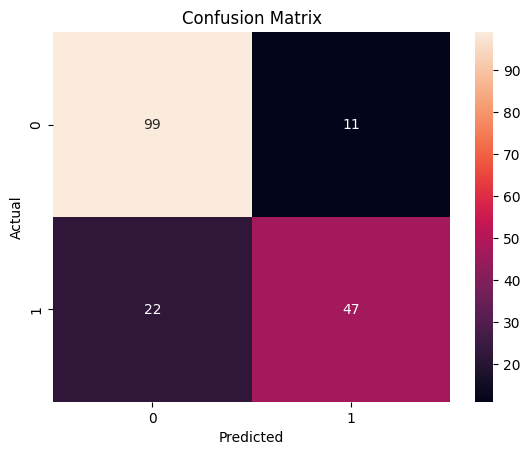

In [31]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


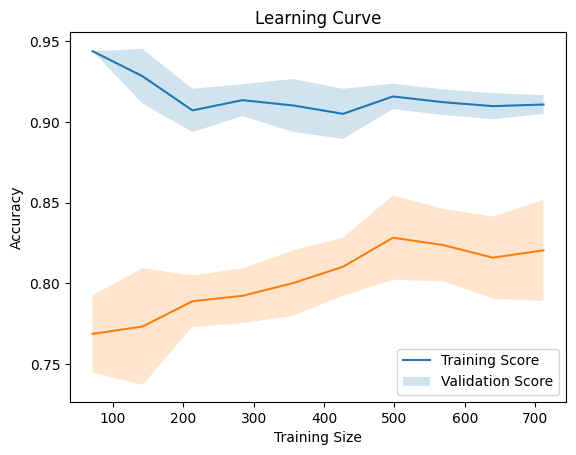

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X,
    y,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure()

# Training curve
plt.plot(train_sizes, train_mean)
plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.2)

# Validation curve
plt.plot(train_sizes, test_mean)
plt.fill_between(train_sizes,
                 test_mean - test_std,
                 test_mean + test_std,
                 alpha=0.2)

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend(["Training Score", "Validation Score"])
plt.show()


In [33]:
import pandas as pd

def create_submission(model, test_df, submission_filename, X_train_columns):
    """
    Creates a Kaggle submission CSV using the trained model.
    
    Parameters:
    - model: trained classifier (best_model)
    - test_df: test dataset (raw)
    - submission_filename: output CSV filename
    - X_train_columns: columns of training features after preprocessing
    """
    
    # Keep PassengerId for submission
    passenger_ids = test_df['PassengerId']
    
    # Select the features used in training
    features = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']
    X_test = pd.get_dummies(test_df[features])
    
    # Align columns with training data
    X_test = X_test.reindex(columns=X_train_columns, fill_value=0)
    
    # Make predictions
    predictions = model.predict(X_test)
    
    # Create submission DataFrame
    output = pd.DataFrame({
        'PassengerId': passenger_ids,
        'Survived': predictions
    })
    
    # Save to CSV
    output.to_csv(submission_filename, index=False)
    print(f"Submission saved to {submission_filename}")


In [34]:
from sklearn.ensemble import HistGradientBoostingClassifier


gbt_model = HistGradientBoostingClassifier(
    max_iter=500,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

gbt_model.fit(X_train, y_train)


y_pred = gbt_model.predict(X_test)
y_proba = gbt_model.predict_proba(X_test)[:, 1]  # for metrics like ROC-AUC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


Accuracy: 0.7988826815642458
Precision: 0.7538461538461538
Recall: 0.7101449275362319
F1 Score: 0.7313432835820896
ROC AUC: 0.7840579710144927


In [35]:
from sklearn.model_selection import GridSearchCV

param_grid_gbt = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_iter': [200, 500]
}

grid_gbt = GridSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_grid_gbt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_gbt.fit(X_train, y_train)

best_gbt = grid_gbt.best_estimator_
print("Best parameters:", grid_gbt.best_params_)


Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'max_iter': 500}


In [36]:
test_data = pd.read_csv("/kaggle/input/titanic/test.csv")

# Call the function
create_submission(best_gbt, test_data, 'submission.csv', X_train.columns)


Submission saved to submission.csv
